# Глубокое обучение 


## Тема 6. Использование EBM ⚡️ для моделирования MNIST 

In [1]:
from silence_tensorflow import silence_tensorflow
silence_tensorflow()

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
tf.__version__

'2.18.0'

In [3]:
import tensorflow.keras as keras

from tensorflow.keras import ( 
    datasets,
    layers,
    models,
    optimizers,
    activations,
    metrics,
    callbacks,
)

import random
import scipy
import sklearn
import sklearn.datasets
import matplotlib.pyplot as plt
import scipy.stats
import seaborn as sns
from sklearn.utils import shuffle as util_shuffle
from functools import partial

In [4]:
def sample_batch(dataset):
    batch = dataset.take(1).get_single_element()
    if isinstance(batch, tuple):
        batch = batch[0]
    return batch.numpy()


def display(
    images, n=10, size=(20, 3), cmap="gray_r", 
    as_type="float32", save_to=None
):
    """
    Displays n random images from each one of the supplied arrays.
    """
    if images.max() > 1.0:
        images = images / 255.0
    elif images.min() < 0.0:
        images = (images + 1.0) / 2.0

    plt.figure(figsize=size)
    for i in range(n):
        _ = plt.subplot(1, n, i + 1)
        plt.imshow(images[i].astype(as_type), cmap=cmap)
        plt.axis("off")

    if save_to:
        plt.savefig(save_to)
        print(f"\nSaved to {save_to}")

    plt.show()


###  Стохастическая градиентная динамика Ланжевена (SGLD)

Стохастическая градиентная динамика Ланжевена (Stochastic Gradient Langevin Dynamics, SGLD) адаптирована для использования стохастических градиентов. Используем формулу 

$$\mathbf{x}^{k+1}=\mathbf{x}^{k}-\frac{\epsilon^{2}}{2}\nabla_{\mathbf{x}}\mathcal{E}_{\theta}\left(\mathbf{x}^{k}\right)+\epsilon\,\mathbf{z}^{k},\,k=0,1,...,K-1,$$
с обрезкой градиентов.

In [5]:
@tf.function
def sgld_sample(E, x_initial, num_steps, step_size, 
                std_dev, clip_thresh=tf.constant(0.1)):
    """
    Do SGLD (stochastic gradient Langevin dynamics) sampling step
    :param E: Energy function
    :param x_initial: initial sample position, of shape 
        (batch_size, ndims)
    :param num_steps: number of sampling steps
    :param step_size: step size used in gradient part
    :param std_dev: standard deviation for isotropic Gaussian 
        used in update
    :param clip_thresh: threshold for gradient clipping; prevents 
        energy gradients from growing too large
    :return: new sample
    """
    x_k = x_initial
    for _ in range(num_steps):
        with tf.GradientTape() as g:
            g.watch(x_k)
            energy = tf.math.reduce_sum(E(x_k))
        # обрезка градиента
        dE_dx = tf.clip_by_norm(g.gradient(energy, x_k), clip_thresh) 
        x_k = x_k - (step_size / 2) * dE_dx + \
            tf.random.normal(x_k.shape, mean=0.0, stddev=std_dev)
    return x_k

I0000 00:00:1762947697.641272 15762784 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1762947697.641294 15762784 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


## Использование EBM для моделирования MNIST

Будем использовать стандартный набор данных MNIST, состоящий из изображений рукописных цифр в оттенках серого.

### Параметры

In [6]:
IMAGE_SIZE = 32
CHANNELS = 1
STEP_SIZE = 10
STEPS = 60
NOISE = 0.005
ALPHA = 0.1
GRADIENT_CLIP = 0.03
BATCH_SIZE = 128
BUFFER_SIZE = 8192
LEARNING_RATE = 0.0001
EPOCHS = 60
LOAD_MODEL = False

In [7]:
import os
# Create subdirectories
for path in ["./checkpoint","./logs","./models","./output"]:
    try:
        os.mkdir(path)
        print("Directory '%s' created successfully" % path)
    except OSError as error:
        print("Directory '%s' exists" % path)


Directory './checkpoint' created successfully
Directory './logs' created successfully
Directory './models' created successfully
Directory './output' created successfully


Загрузим набор средствами TensorFlow:

In [8]:
# Load the data
(x_train, _), (x_test, _) = datasets.mnist.load_data()

Масштабируем значения пикселей до диапазона $[-1, 1]$ и добавим некоторые отступы, чтобы сделать изображения размером 32 × 32 пикселя. Также преобразуем его в набор данных TensorFlow:

In [9]:
# Preprocess the data


def preprocess(imgs):
    """
    Normalize and reshape the images
    """
    imgs = (imgs.astype("float32") - 127.5) / 127.5
    imgs = np.pad(imgs, ((0, 0), (2, 2), (2, 2)), constant_values=-1.0)
    imgs = np.expand_dims(imgs, -1)
    return imgs


x_train = preprocess(x_train)
x_test = preprocess(x_test)

In [10]:
x_train = tf.data.Dataset.from_tensor_slices(x_train).batch(BATCH_SIZE)
x_test = tf.data.Dataset.from_tensor_slices(x_test).batch(BATCH_SIZE)

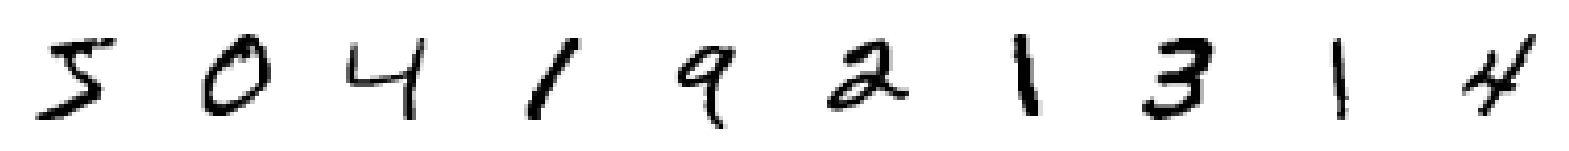

In [11]:
# Show some digits from the training set
train_sample = sample_batch(x_train)
display(train_sample)

Теперь, когда у нас есть набор данных, мы можем построить нейронную сеть, которая будет представлять функцию энергии $\mathcal{E}_{\theta}\left(\mathbf{x}\right)$.

### Функция энергии 

Функция энергии $\mathcal{E}_{\theta}\left(\mathbf{x}\right)$ представляет собой нейронную сеть с параметрами $\theta$, которая может преобразовывать входное изображение $\mathbf{x}$ в скалярное значение. В этой сети мы используем функцию активации под названием `swish`.

Функция `swish` — это альтернатива `ReLU`, представленная Google в 2017 году и определяемая следующим образом:

$$\mathrm{swish}\left(x\right)=x\cdot\mathrm{sigmoid}\left(x\right)=\frac{x}{e^{-x}+1}$$

Функция `swish` визуально похожа на `ReLU` с ключевым отличием в том, что она гладкая, что помогает решить проблему исчезновения градиента. Это особенно важно для энергетических моделей. Ниже показан график функции `swish`.

<!--img src="11_EBM_01.pdf" width=600-->

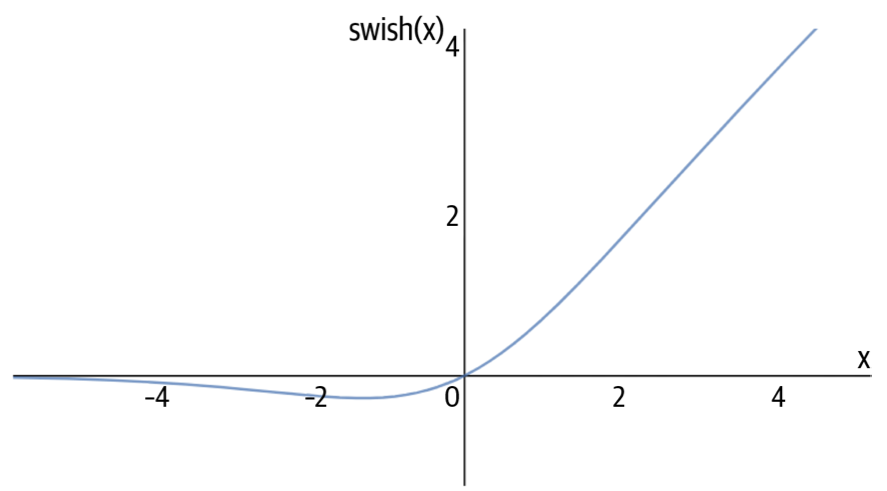

### Построение сети EBM 

Модель представляет собой набор сложенных слоев `Conv2D`, которые постепенно уменьшают размер изображения, одновременно увеличивая количество каналов. Последний слой представляет собой полносвязный слой с одним нейроном стью подключенный блок с линейной активацией, поэтому сеть может выводить значения в диапазоне $\left(-\infty,+\infty\right)$. Код для построения модели приведен ниже.

In [12]:
ebm_input = layers.Input(shape=(IMAGE_SIZE, IMAGE_SIZE, CHANNELS))
x = layers.Conv2D(
    16, kernel_size=5, strides=2, padding="same", activation=activations.swish
)(ebm_input) # 1)
x = layers.Conv2D(
    32, kernel_size=3, strides=2, padding="same", activation=activations.swish
)(x)
x = layers.Conv2D(
    64, kernel_size=3, strides=2, padding="same", activation=activations.swish
)(x)
x = layers.Conv2D(
    64, kernel_size=3, strides=2, padding="same", activation=activations.swish
)(x)
x = layers.Flatten()(x)
x = layers.Dense(64, activation=activations.swish)(x)
ebm_output = layers.Dense(1)(x) # 2)
model = models.Model(ebm_input, ebm_output) # 3)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 16, 16, 16)     │           416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 8, 8, 32)       │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 2, 2, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 76,993 (300.75 KB)

 Trainable params: 76,993 (300.75 KB)

 Non-trainable params: 0 (0.00 B)

Здесь:
1. Функция энергии представляет собой набор сложенных слоев `Conv2D` с активацией `swish`. 

2. Последний слой представляет собой один полносвязный нейрон с линейной функцией активации. 

3. Модель Keras, которая преобразует входное изображение в скалярное значение энергии.

In [13]:
if LOAD_MODEL:
    model.load_weights("./models/model.weights.h5")

### Выборка с использованием динамики Ланжевена

Функция энергии выводит оценку только для заданных входных данных — как мы можем использовать эту функцию для создания новых образцов с низким показателем энергии (правдоподобных наблюдений)? 

Мы будем использовать метод, называемый динамикой Ланжевена (Langevin dynamics), который использует тот факт, что мы можем вычислить градиент функции энергии по отношению к ее входным данным. Если мы начнем со случайной точки выборочного пространства и сделаем небольшие шаги в направлении, противоположном рассчитанному градиенту, то мы постепенно уменьшим функцию энергии. Если наша нейронная сеть обучена правильно, то случайный шум должен на наших глазах превратиться в изображение, напоминающее наблюдение из обучающей выборки.

Важно отметить, что мы также должны добавить к входным данным небольшое количество случайного шума при перемещении по выборочному пространству – в противном случае существует риск попадания в локальные минимумы. Поэтому этот метод известен как стохастическая градиентная динамика Ланжевена.

Мы можем визуализировать этот градиентный спуск, как показано на рисунке ниже, для двумерного пространства со значением функции энергии в третьем измерении. Путь представляет собой зашумленный спуск вниз по отрицательному градиенту функции энергии $\mathcal{E}_{\theta}\left(\mathbf{x}\right)$ по отношению к входным данным $\mathbf{x}$. В наборе данных изображений MNIST у нас 1024 пикселя, поэтому мы перемещаемся в 1024-мерном пространстве, но применяются те же принципы.

<!--img src="11_EBM_02.pdf" width=600-->

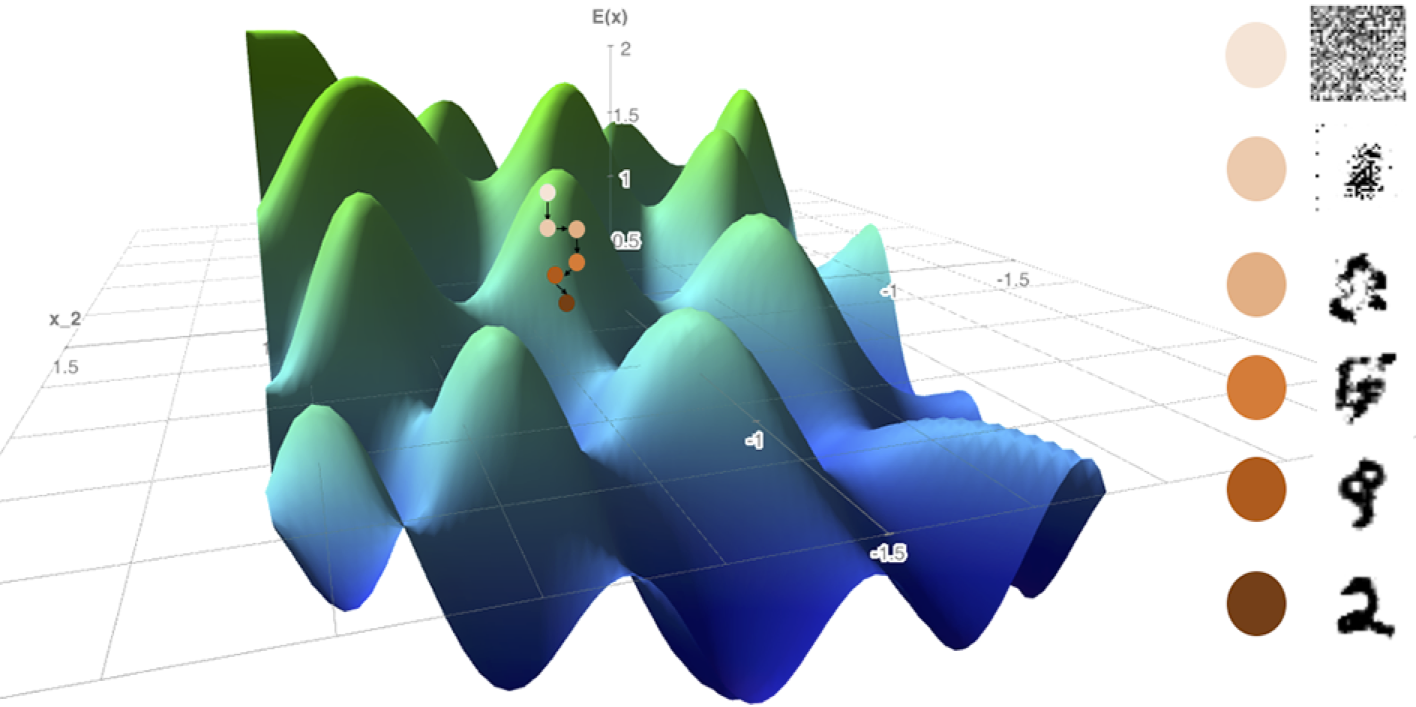

Стоит отметить разницу между этим видом градиентного спуска и тем видом градиентного спуска, который мы обычно используем для обучения нейронной сети. 

При обучении нейронной сети мы вычисляем градиент функции потерь относительно параметров сети (т. е. весов) с помощью обратного распространения ошибки. Затем мы немного обновляем параметры сети в направлении отрицательного градиента, чтобы в течение многих итераций постепенно минимизировать потери. 

С помощью динамики Ланжевена мы сохраняем фиксированные веса нейронной сети и вычисляем градиент выходных данных по отношению к входным данным. Затем мы немного обновляем входные данные в направлении отрицательного градиента, так что в течение многих итераций мы постепенно минимизируем выходные данные (показатель энергии). 

Оба процесса используют одну и ту же идею (градиентный спуск), но применяются к разным функциям и по отношению к разным объектам.

Формально используемую здесь динамику Ланжевена можно описать следующим уравнением:

$$\mathbf{x}^{k}=\mathbf{x}^{k-1}-\eta\,\nabla_{\mathbf{x}}\mathcal{E}_{\theta}\left(\mathbf{x}^{k-1}\right)+\omega,$$

где $\omega\sim\mathcal{N}\left(0,\sigma^{2}\right)$ и $\mathbf{x}^{0}\sim\mathcal{U}\left(-1,\,1\right)$ (здесь $\mathcal{N}\left(0,\sigma\right)$ – нормальное распределение с нулевым матожиданием и дисперсией $\sigma^{2}$ и $\mathcal{U}\left(-1,\,1\right)$ – равномерное распределение в диапазоне $\left[-1,\,1\right]$). Величина $\eta$ — это гиперпараметр размера шага, который необходимо настроить: если он слишком большой, то шаги перескакивают через минимумы, если слишком маленький, то алгоритм будет сходиться слишком медленно.

Можно закодировать нашу функцию выборки Ланжевена, как показано ниже.

In [14]:
# Function to generate samples using Langevin Dynamics
def generate_samples(
    model, inp_imgs, steps, step_size, noise, return_img_per_step=False
):
    imgs_per_step = []
    for _ in range(steps):                                              # 1)
        inp_imgs += tf.random.normal(inp_imgs.shape, mean=0, 
                                     stddev=noise)                      # 2)
        inp_imgs = tf.clip_by_value(inp_imgs, -1.0, 1.0)
        with tf.GradientTape() as tape:
            tape.watch(inp_imgs)
            out_score = model(inp_imgs)                                 # 3)
        grads = tape.gradient(out_score, inp_imgs)                      # 4)
        grads = tf.clip_by_value(grads, -GRADIENT_CLIP, GRADIENT_CLIP)
        inp_imgs += step_size * grads                                   # 5)
        inp_imgs = tf.clip_by_value(inp_imgs, -1.0, 1.0)
        if return_img_per_step:
            imgs_per_step.append(inp_imgs)
    if return_img_per_step:
        return tf.stack(imgs_per_step, axis=0)
    else:
        return inp_imgs

Здесь делается следующее:

1. Цикл по заданному количеству шагов. 

2. Добавим небольшое количество шума к изображению. 

3. Передадим изображение через модель, чтобы получить оценку энергии. 

4. Вычислим градиент выхода по отношению к входу. 

5. Добавим небольшое количество градиента к входному изображению.

### Обучение с контрастной дивергенцией 

Теперь, когда мы знаем, как выбрать новую точку с низкой энергией из пространства выборки, давайте обратим внимание на обучение модели. 

Мы не можем применить оценку максимального правдоподобия, потому что функция энергии не выводит вероятность; она выводит оценку, которая не интегрируется до единицы по всему пространству выборки. Вместо этого мы применим метод, называемый __контрастной дивергенцией__ (contrastive divergence), для обучения ненормализованных оценочных моделей. Значение, которое, как всегда, мы хотим минимизировать — это отрицательное логарифмическое правдоподобие данных:

$$\mathscr{L}=-\mathbb{E}_{\mathbf{x}\sim data}\left[\log p_{\theta}\left(\mathbf{x}\right)\right]$$

Когда $p_{\theta}\left(\mathbf{x}\right)$ имеет форму распределения Больцмана с функцией энергии $\mathcal{E}_{\theta}\left(\mathbf{x}\right)$, можно показать, что градиент этой величины можно записать следующим образом:

$$\nabla_{\theta}\mathscr{L}=\mathbb{E}_{\mathbf{x}\sim data}\left[\nabla_{\theta}\mathcal{E}_{\theta}\left(\mathbf{x}\right)\right]-\mathbb{E}_{\mathbf{x}\sim model}\left[\nabla_{\theta}\mathcal{E}_{\theta}\left(\mathbf{x}\right)\right]$$

Интуитивно это имеет большой смысл: мы хотим обучить модель выдавать большие отрицательные показатели энергии для реальных наблюдений и большие положительные показатели энергии для сгенерированных наблюдений, чтобы контраст между этими двумя крайностями был как можно большим. 

Другими словами, мы можем вычислить разницу между показателями энергии реальных и сгенерированных образцов и использовать ее в качестве функции потерь. 

Чтобы вычислить показатели энергии сгенерированных образцов, нам нужно будет иметь возможность осуществлять выборку точно из распределения $p_{\theta}\left(\mathbf{x}\right)$, что невозможно из-за сложного знаменателя. Вместо этого мы можем использовать нашу процедуру выборки Ланжевена для создания набора наблюдений с низкими энергетическими показателями. Чтобы получить идеальную выборку, процесс должен будет выполняться бесконечно много шагов (что, очевидно, не реально), поэтому вместо этого мы выполняем некоторое небольшое количество шагов, предполагая, что этого достаточно, чтобы получить значимую функцию потерь. 

### Создание буфера для хранения данных

Будем поддерживать буфер выборок из предыдущих итераций, чтобы мы могли использовать его в качестве отправной точки для следующего пакета, а не чистый случайный шум. Код для создания буфера выборок показан ниже.

In [15]:
class Buffer:
    def __init__(self, model):
        super().__init__()
        self.model = model
        self.examples = [
            tf.random.uniform(shape=(1, IMAGE_SIZE, IMAGE_SIZE, CHANNELS)) * 2
            - 1
            for _ in range(BATCH_SIZE)
        ]                                                                          # 1)

    def sample_new_exmps(self, steps, step_size, noise):
        n_new = np.random.binomial(BATCH_SIZE, 0.05)                               # 2)
        rand_imgs = (
            tf.random.uniform((n_new, IMAGE_SIZE, IMAGE_SIZE, CHANNELS)) * 2 - 1
        )
        old_imgs = tf.concat(
            random.choices(self.examples, k=BATCH_SIZE - n_new), axis=0
        )                                                                          # 3)
        inp_imgs = tf.concat([rand_imgs, old_imgs], axis=0)
        inp_imgs = generate_samples(
            self.model, inp_imgs, steps=steps, step_size=step_size, noise=noise
        )                                                                          # 4)
        self.examples = tf.split(inp_imgs, BATCH_SIZE, axis=0) + self.examples     # 5)
        self.examples = self.examples[:BUFFER_SIZE]
        return inp_imgs

1. Буфер выборок инициализируется пакетом случайного шума. 

2. В среднем 5% наблюдений каждый раз генерируются с нуля (т.е. случайный шум). 

3. Остальные извлекаются случайным образом из существующего буфера. 

4. Наблюдения объединяются и пропускаются через процедуру выборки Ланжевена. 

5. Полученная выборка добавляется в буфер, который обрезается до максимальной длины в 8192 наблюдения. 

На рисунке ниже показан один этап обучения с контрастной дивергенцией. Алгоритм понижает оценки реальных наблюдений, а оценки сгенерированных наблюдений поднимает, не заботясь о нормализации этих оценок после каждого шага.

<!--img src="11_EBM_03.pdf" width=600-->

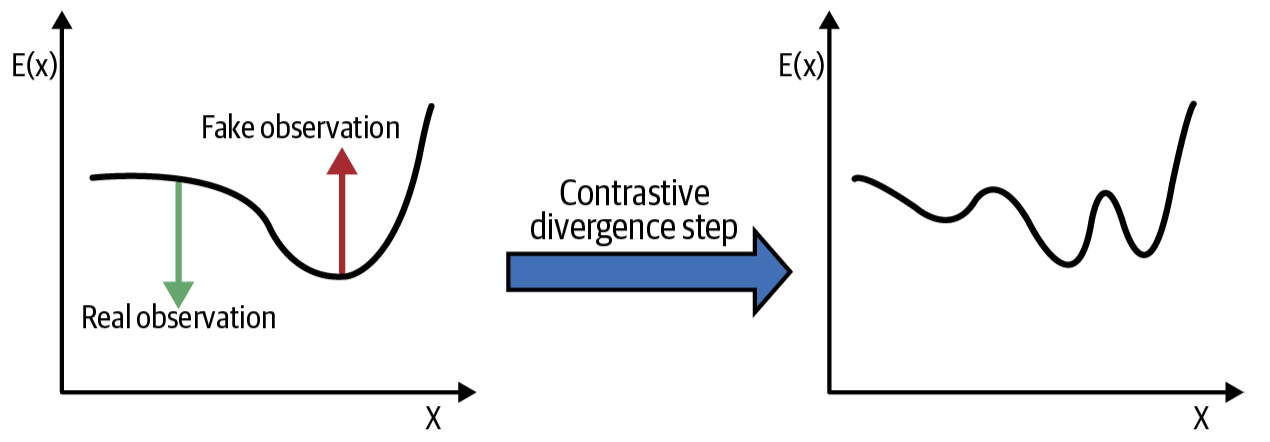

Мы можем закодировать этап обучения алгоритма с контрастной дивергенцией в модели Keras, как показано ниже.

In [16]:
class EBM2(models.Model):
    def __init__(self):
        super(EBM2, self).__init__()
        self.model = model
        self.buffer = Buffer(self.model)
        self.alpha = ALPHA
        self.loss_metric = metrics.Mean(name="loss")
        self.reg_loss_metric = metrics.Mean(name="reg")
        self.cdiv_loss_metric = metrics.Mean(name="cdiv")
        self.real_out_metric = metrics.Mean(name="real")
        self.fake_out_metric = metrics.Mean(name="fake")

    @property
    def metrics(self):
        return [
            self.loss_metric,
            self.reg_loss_metric,
            self.cdiv_loss_metric,
            self.real_out_metric,
            self.fake_out_metric,
        ]

    def train_step(self, real_imgs):
        real_imgs += tf.random.normal(
            shape=tf.shape(real_imgs), mean=0, stddev=NOISE
        )                                                                    # 1)
        real_imgs = tf.clip_by_value(real_imgs, -1.0, 1.0)
        fake_imgs = self.buffer.sample_new_exmps(
            steps=STEPS, step_size=STEP_SIZE, noise=NOISE
        )                                                                    # 2)
        inp_imgs = tf.concat([real_imgs, fake_imgs], axis=0)
        with tf.GradientTape() as training_tape:
            real_out,fake_out = tf.split(self.model(inp_imgs),2,axis=0)      # 3)
            cdiv_loss = tf.reduce_mean(fake_out, axis=0) - tf.reduce_mean(
                real_out, axis=0
            )                                                                # 4)
            reg_loss = self.alpha * tf.reduce_mean(
                real_out**2 + fake_out**2, axis=0
            )                                                                # 5)
            loss = cdiv_loss + reg_loss
        grads = training_tape.gradient(loss, 
                                       self.model.trainable_variables)       # 6)
        self.optimizer.apply_gradients(
            zip(grads, self.model.trainable_variables)
        )
        self.loss_metric.update_state(loss)
        self.reg_loss_metric.update_state(reg_loss)
        self.cdiv_loss_metric.update_state(cdiv_loss)
        self.real_out_metric.update_state(tf.reduce_mean(real_out, axis=0))
        self.fake_out_metric.update_state(tf.reduce_mean(fake_out, axis=0))
        return {m.name: m.result() for m in self.metrics}

    def test_step(self, real_imgs):                                           # 7)
        batch_size = real_imgs.shape[0]
        fake_imgs = (
            tf.random.uniform((batch_size, IMAGE_SIZE, IMAGE_SIZE, CHANNELS))
            * 2
            - 1
        )
        inp_imgs = tf.concat([real_imgs, fake_imgs], axis=0)
        real_out, fake_out = tf.split(self.model(inp_imgs), 2, axis=0)
        cdiv = tf.reduce_mean(fake_out, axis=0) - tf.reduce_mean(
            real_out, axis=0
        )
        self.cdiv_loss_metric.update_state(cdiv)
        self.real_out_metric.update_state(tf.reduce_mean(real_out, axis=0))
        self.fake_out_metric.update_state(tf.reduce_mean(fake_out, axis=0))
        return {m.name: m.result() for m in self.metrics[2:]}

1. К реальным изображениям добавляется небольшое количество случайного шума, чтобы избежать переобучения модели на обучающем наборе данных. 

2. Из буфера выбирается набор поддельных изображений. 

3. Реальные и поддельные изображения пропускаются через модель для получения реальных и поддельных оценок. 

4. Потери контрастной дивергенции — это просто разница между оценками реальных и ложных наблюдений. 

5. Потери регуляризации добавляются, чтобы избежать слишком больших оценок. 

6. Градиенты функции потерь относительно весов сети рассчитываются для обратного распространения ошибки. 

7. Метод `test_step` используется во время валидации и вычисляет контрастное расхождение между оценками набора случайного шума и данными из обучающего набора. Его можно использовать как меру того, насколько хорошо обучается модель.

In [17]:
ebm = EBM2()

### Обучение сети EBM 

In [18]:
# Compile and train the model
ebm.compile(
    optimizer=optimizers.Adam(learning_rate=LEARNING_RATE), run_eagerly=True
)

In [19]:
tensorboard_callback = callbacks.TensorBoard(log_dir="./logs")


class ImageGenerator(callbacks.Callback):
    def __init__(self, num_img):
        self.num_img = num_img

    def on_epoch_end(self, epoch, logs=None):
        start_imgs = (
            np.random.uniform(
                size=(self.num_img, IMAGE_SIZE, IMAGE_SIZE, CHANNELS)
            )
            * 2
            - 1
        )
        generated_images = generate_samples(
            ebm.model,
            start_imgs,
            steps=1000,
            step_size=STEP_SIZE,
            noise=NOISE,
            return_img_per_step=False,
        )
        generated_images = generated_images.numpy()
        display(
            generated_images,
            save_to="./output/generated_img_%03d.png" % (epoch),
        )

        example_images = tf.concat(
            random.choices(ebm.buffer.examples, k=10), axis=0
        )
        example_images = example_images.numpy()
        display(
            example_images, save_to="./output/example_img_%03d.png" % (epoch)
        )


image_generator_callback = ImageGenerator(num_img=10)

In [20]:
class SaveModel(callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        model.save_weights("./models/model.weights.h5")


save_model_callback = SaveModel()

Epoch 1/2
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 660ms/step - cdiv: -0.0670 - fake: 0.2494 - loss: -0.0413 - real: 0.3164 - reg: 0.0257
Saved to ./output/generated_img_000.png


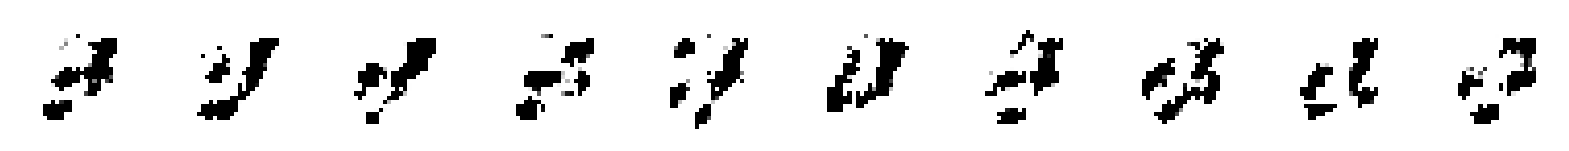


Saved to ./output/example_img_000.png


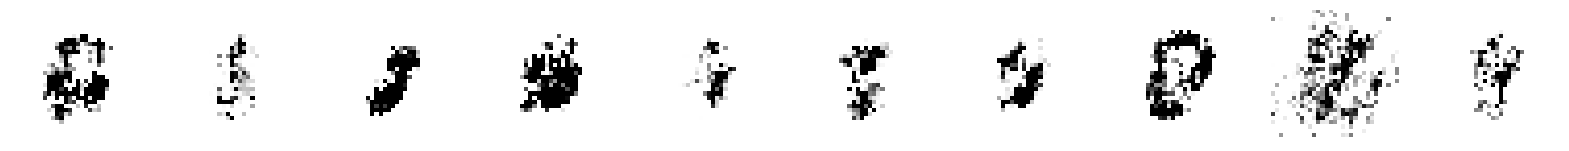

469/469 ━━━━━━━━━━━━━━━━━━━━ 324s 684ms/step - cdiv: -0.0601 - fake: 0.1965 - loss: -0.0417 - real: 0.2566 - reg: 0.0185 - val_cdiv: -1.2363 - val_fake: -1.2444 - val_real: -0.0081
Epoch 2/2
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 658ms/step - cdiv: -0.0181 - fake: 0.0189 - loss: -0.0136 - real: 0.0370 - reg: 0.0046
Saved to ./output/generated_img_001.png


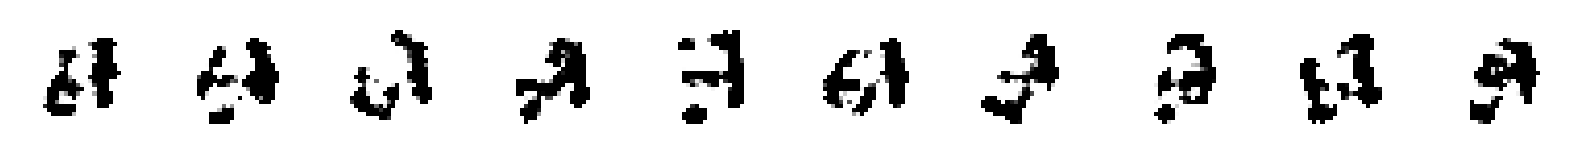


Saved to ./output/example_img_001.png


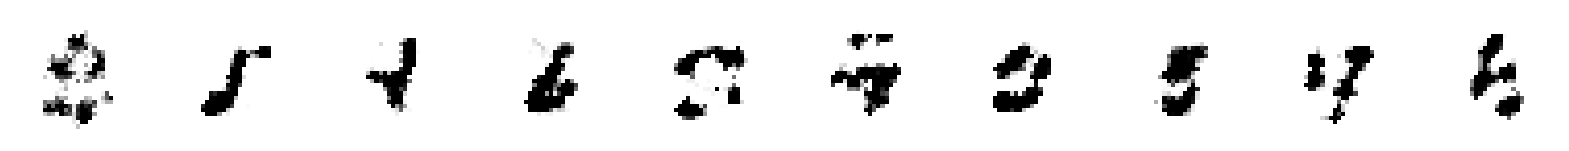

469/469 ━━━━━━━━━━━━━━━━━━━━ 319s 680ms/step - cdiv: -0.0138 - fake: 0.0089 - loss: -0.0100 - real: 0.0227 - reg: 0.0038 - val_cdiv: -1.7767 - val_fake: -1.8404 - val_real: -0.0637


In [21]:
ebm.fit(
    x_train,
    shuffle=True,
    epochs=2,
    validation_data=x_test,
    callbacks=[
        save_model_callback,
        tensorboard_callback,
        image_generator_callback,
    ],
)

Кривые потерь и вспомогательные показатели процесса обучения показаны на рисунке ниже.

<!--img src="11_EBM_04.pdf" width=600-->

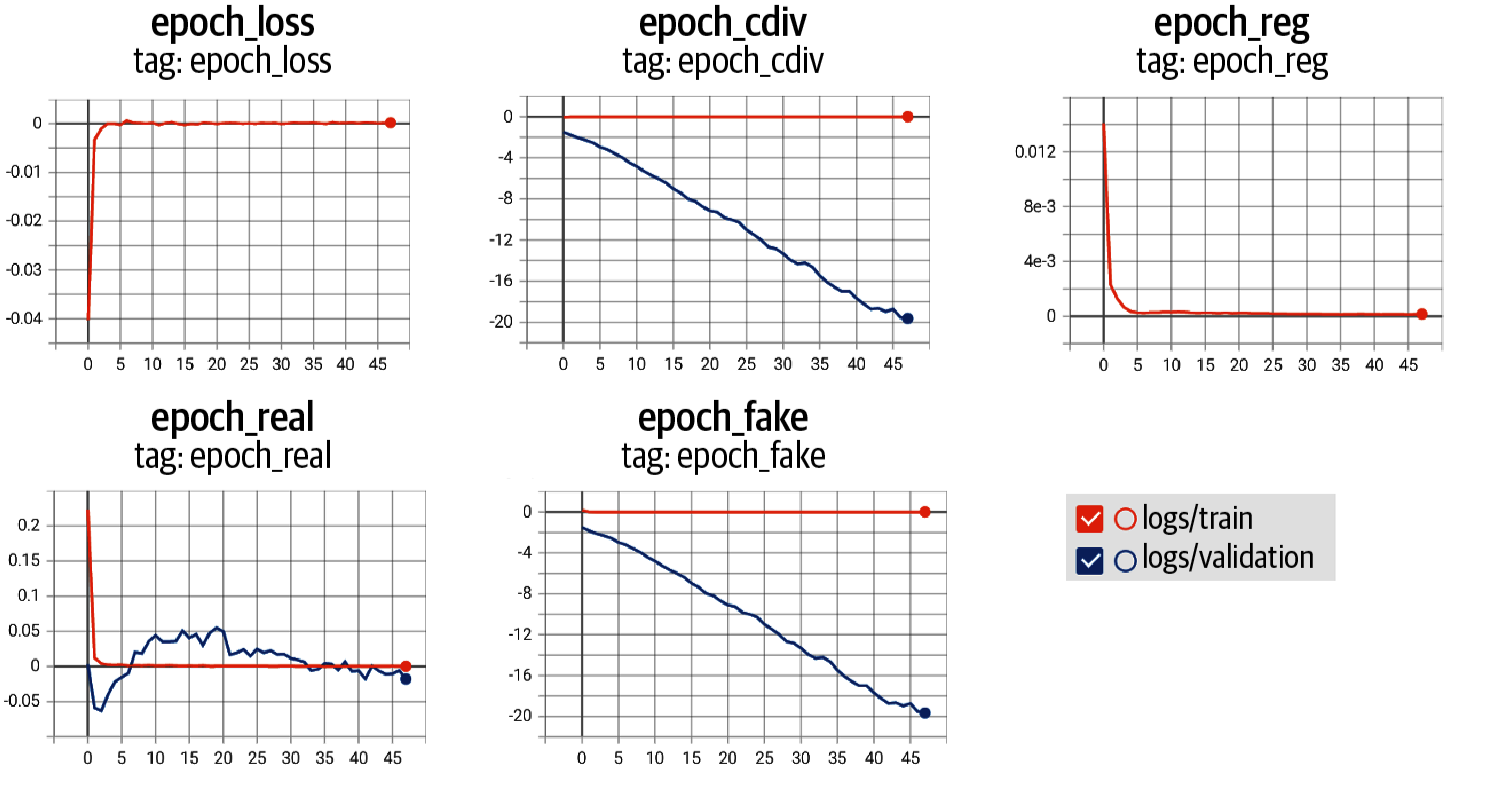

Обратите внимание, что потери, рассчитанные на этапе обучения, примерно постоянны и малы от эпохи к эпохе. Несмотря на то, что модель постоянно улучшается, качество сгенерированных изображений в буфере, которые необходимо сравнивать с реальными изображениями из обучающего набора, также улучшается, поэтому нам не следует ожидать значительного снижения потерь при обучении. 

Поэтому, чтобы оценить производительность модели, также настраивается процесс проверки, который не выполняет выборку из буфера, а вместо этого оценивает выборку при помощи случайного шума и сравнивает ее с оценками примеров из обучающего набора. Если модель улучшается, мы должны увидеть, что контрастная дивергенция падает (растет по модулю) с течением эпох (т. е. она лучше отличает случайный шум от реальных изображений), как это видно на рисунке выше.

### Генерация изображений

Генерация новых экземпляров из модели EBM — это просто запуск процедуры выборки (сэмплера) Ланжевена на большое количество шагов с нуля (случайный шум), как показано в примере ниже. Наблюдение принудительно опускается вниз (по уровню энергии), следуя градиентам оценочной функции по отношению к входным данным, так что из шума появляется правдоподобное наблюдение.

In [22]:
start_imgs = (
    np.random.uniform(size=(10, IMAGE_SIZE, IMAGE_SIZE, CHANNELS)) * 2 - 1
)

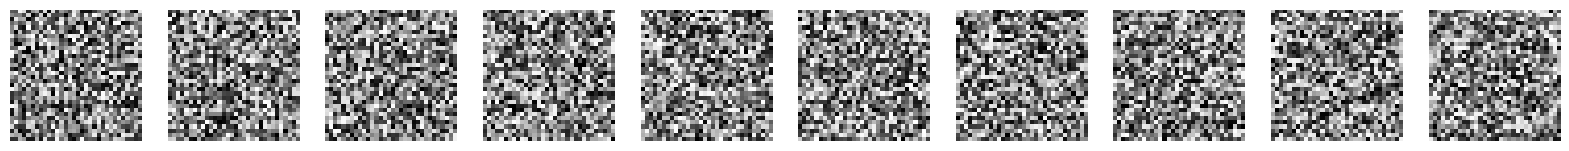

In [23]:
display(start_imgs)

In [24]:
gen_img = generate_samples(
    ebm.model,
    start_imgs,
    steps=1000,
    step_size=STEP_SIZE,
    noise=NOISE,
    return_img_per_step=True,
)

Показаны некоторые примеры наблюдений, сгенерированных сэмплером после 50 эпох обучения.

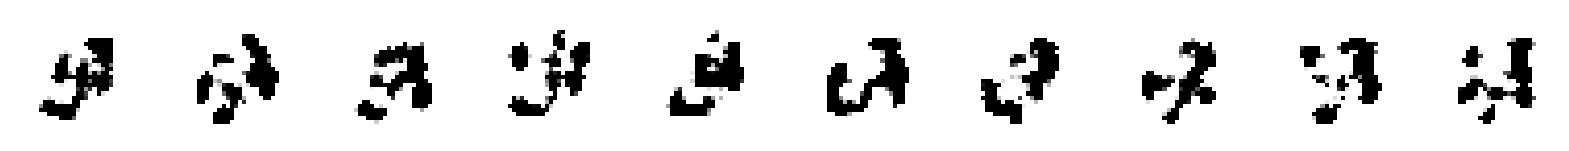

In [25]:
display(gen_img[-1].numpy())

Мы можем даже воспроизвести то, как генерируется отдельное наблюдение, делая снимки текущих наблюдений во время процесса выборки Ланжевена — это показано ниже.

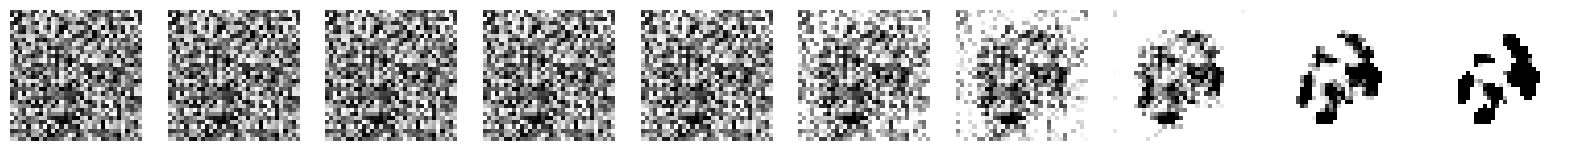

In [26]:
imgs = []
for i in [0, 1, 3, 5, 10, 30, 50, 100, 300, 999]:
    imgs.append(gen_img[i].numpy()[1])

display(np.array(imgs))

### Итоги

__Энергетические модели__ (EBM) — это класс генеративных моделей, в которых используется функция оценки на основе __энергии__ — нейронной сети, обученной выдавать низкие оценки для реальных наблюдений и высокие оценки для сгенерированных наблюдений. Расчет распределения вероятностей, заданного этой функцией оценки, требует нормализации с помощью трудноразрешимого знаменателя. Модели EBM избегают этой проблемы, используя два приема: контрастную дивергенцию для обучения сети и динамику Ланжевена для выборки новых наблюдений. 

Функция энергии обучается путем минимизации разницы между оценками сгенерированных данных и оценками обучающих данных – метод, известный как __контрастная дивергенция__. Можно показать, что это эквивалентно минимизации отрицательного логарифмического правдоподобия, как того требует оценка максимального правдоподобия, но не требует от нас вычисления трудноразрешимого нормализующего знаменателя. На практике мы аппроксимируем процесс выборки сгенерированных образцов, чтобы гарантировать эффективность алгоритма. 

Выборка для глубоких EBM достигается с помощью __динамики Ланжевена__ — метода, который использует градиент оценки по отношению к входному изображению для постепенного преобразования случайного шума в правдоподобное наблюдение путем обновления входных данных небольшими шагами, следуя за градиентом вниз. Это улучшает более ранние методы, такие как выборка Гиббса, которая используется ограниченными машинами Больцмана (RBM).

## Задание

Используя функцию `sklearn.datasets.make_moons` фреймворка `scikit-learn` 

* создайте датасет в виде двух полумесяцев, визуализируйте этот датасет и оценку плотности распределения для этого датасета  
* создайте модель архитектуры EMB для изучения распределения данных датасета
* обучите модель EMB на сгенерированном датасете в виде двух полумесяцев
* визуализируйте функцию энергии обученной модели
* при помощи обученной сети EBM сгенерируйте и визуализируйте набор точек на плоскости
* визуализируйте плотность распределения, определенную функцией энергии
* оцените качество генеративной модели по показателю KL-дивергенции (можно использовать функцию `tf.keras.losses.KLDivergence`) и расстояния Дженсена-Шеннона (можно использовать функцию `scipy.spatial.distance.jensenshannon`)